In [57]:
import	pandas	as	pd,	sqlite3

In [58]:
import	matplotlib.pyplot	as	plt

In [59]:
conn	=	sqlite3.connect("data/opal.db")

In [60]:
monthly	=	pd.read_sql("""
SELECT	year,	month,	mode_name,	SUM(trips)	AS	trips
FROM	patronage
WHERE	data_quality_flag	=	0	AND	is_nsw_total	=	1
GROUP	BY	year,	month,	mode_name
""",	conn)
monthly['date']	=	pd.to_datetime(dict(year=monthly.year,	month=monthly.month,	day=1))

In [61]:
monthly

,year,month,mode_name,trips,date
0,2020,1,Bus,19154000,2020-01-01
1,2020,1,Ferry,1471975,2020-01-01
2,2020,1,Light rail,2133200,2020-01-01
3,2020,1,Train,30573350,2020-01-01
4,2020,2,Bus,21871000,2020-02-01
...,...,...,...,...,...
307,2026,5,Train,29759500,2026-05-01
308,2026,6,Bus,21449000,2026-06-01
309,2026,6,Ferry,1351500,2026-06-01
310,2026,6,Light rail,3972350,2026-06-01


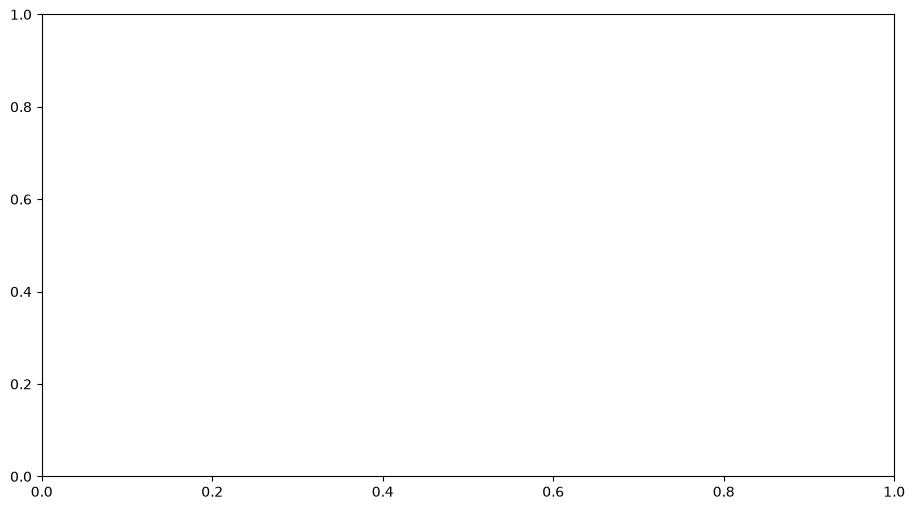

In [62]:
fig,	ax	=	plt.subplots(figsize=(11,6))

In [63]:
for mode, g in monthly.groupby('mode_name'):
    ax.plot(g['date'],	g['trips'],	label=mode)

In [64]:
ax.set_title("Sydney Opal patronage	by mode, 2020 onward")

Text(0.5, 1.0, 'Sydney Opal patronage\tby mode, 2020 onward')

In [65]:
ax.set_xlabel("Date");	ax.set_ylabel("Monthly	trips");	ax.legend()

In [66]:
plt.savefig("images/patronage_by_mode.png",	dpi=150,	bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

In [67]:
plt.show()

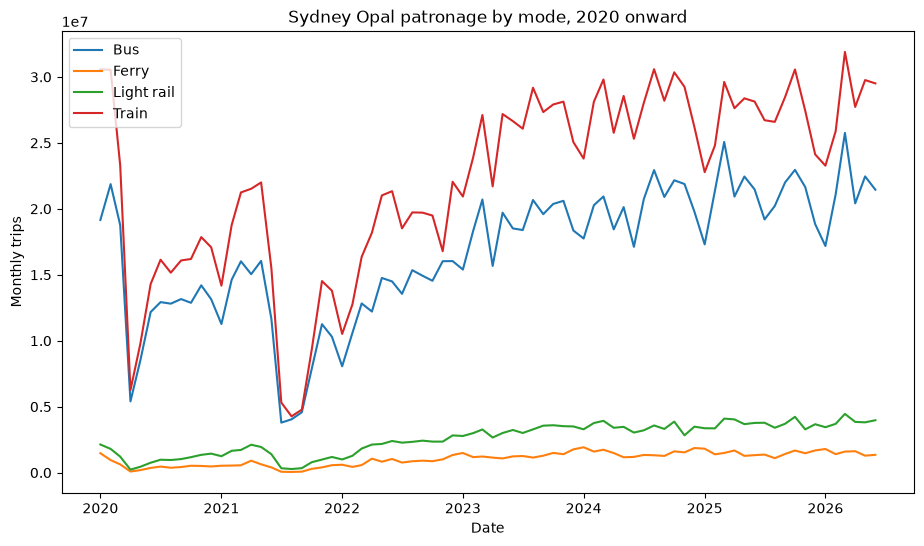

In [72]:
import pandas as pd, sqlite3import matplotlib.pyplot as pltconn = sqlite3.connect("data/opal.db")monthly = pd.read_sql('''  SELECT year, month, mode_name, SUM(trips) AS trips  FROM patronage  WHERE data_quality_flag = 0 AND is_nsw_total = 1  GROUP BY year, month, mode_name''', conn)monthly['date'] = pd.to_datetime(    dict(year=monthly.year, month=monthly.month, day=1))	fig, ax = plt.subplots(figsize=(11,6))for mode, g in monthly.groupby('mode_name'):    ax.plot(g['date'], g['trips'], label=mode)
ax.set_title("Sydney Opal patronage by mode, 2020 onward")
ax.set_xlabel("Date");	ax.set_ylabel("Monthly trips");	ax.legend()plt.savefig("images/patronage_by_mode.png", dpi=150)